# Tâche 3 — Correction du data leakage : SelectKBest

Ce notebook compare deux approches de sélection de features avec SelectKBest sur le dataset ABIDE :

- **Approche 1** — SelectKBest appliqué avant la CV (data leakage)
- **Approche 2** — SelectKBest intégré dans un pipeline CV (corrigé)

Classifieur : LinearSVC  
CV : GroupKFold(10) avec groups=sites

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score

sys.path.insert(0, os.path.dirname(os.path.dirname(os.getcwd())))
import prepare_data_v2

In [ ]:
data_dir   = os.environ.get('SOURCE_DATA_DIR', '../../data')
output_dir = os.environ.get('OUTPUT_DATA_DIR', '../output')

X, y = prepare_data_v2.prepare_data(data_dir, output_dir, n_subjects=40)
X = np.array(X)
y = np.array(y)

abide  = datasets.fetch_abide_pcp(data_dir=data_dir, pipeline='cpac', quality_checked=True, n_subjects=40)
pheno  = pd.DataFrame(abide.phenotypic)
groups = [s.decode() if isinstance(s, bytes) else s for s in pheno.SITE_ID]

print(f'Features shape : {X.shape}')
print(f'{X.shape[0]} sujets · {len(set(groups))} sites')

## Approche 1 — SelectKBest avant CV (leakage)

In [3]:
X_kbest = SelectKBest(f_classif, k=100).fit_transform(X, y)

print(f'Dimensions après SelectKBest : {X_kbest.shape[1]} features')

clf = LinearSVC(max_iter=10000)
gkf = GroupKFold(n_splits=10)

scores_leakage = cross_val_score(clf, X_kbest, y, groups=groups, cv=gkf, n_jobs=-1)

print(f'\nApproche 1 — SelectKBest avant CV (leakage)')
print(f'  Accuracy par fold : {np.round(scores_leakage, 3)}')
print(f'  Moyenne           : {scores_leakage.mean():.3f}')
print(f'  Ecart-type        : {scores_leakage.std():.3f}')

Dimensions après SelectKBest : 100 features



Approche 1 — SelectKBest avant CV (leakage)
  Accuracy par fold : [0.669 0.674 0.692 0.608 0.68  0.556 0.634 0.667 0.675 0.628]
  Moyenne           : 0.648
  Ecart-type        : 0.040


## Approche 2 — SelectKBest dans le pipeline CV (corrigé)

In [4]:
pipeline = Pipeline([
    ('selector', SelectKBest(f_classif, k=100)),
    ('clf',      LinearSVC(max_iter=10000))
])

gkf = GroupKFold(n_splits=10)

scores_corrected = cross_val_score(pipeline, X, y, groups=groups, cv=gkf, n_jobs=-1)

print(f'Approche 2 — SelectKBest dans le pipeline CV (corrigé)')
print(f'  Accuracy par fold : {np.round(scores_corrected, 3)}')
print(f'  Moyenne           : {scores_corrected.mean():.3f}')
print(f'  Ecart-type        : {scores_corrected.std():.3f}')

Approche 2 — SelectKBest dans le pipeline CV (corrigé)
  Accuracy par fold : [0.634 0.512 0.654 0.582 0.653 0.556 0.592 0.667 0.675 0.581]
  Moyenne           : 0.610
  Ecart-type        : 0.051


## Visualisation

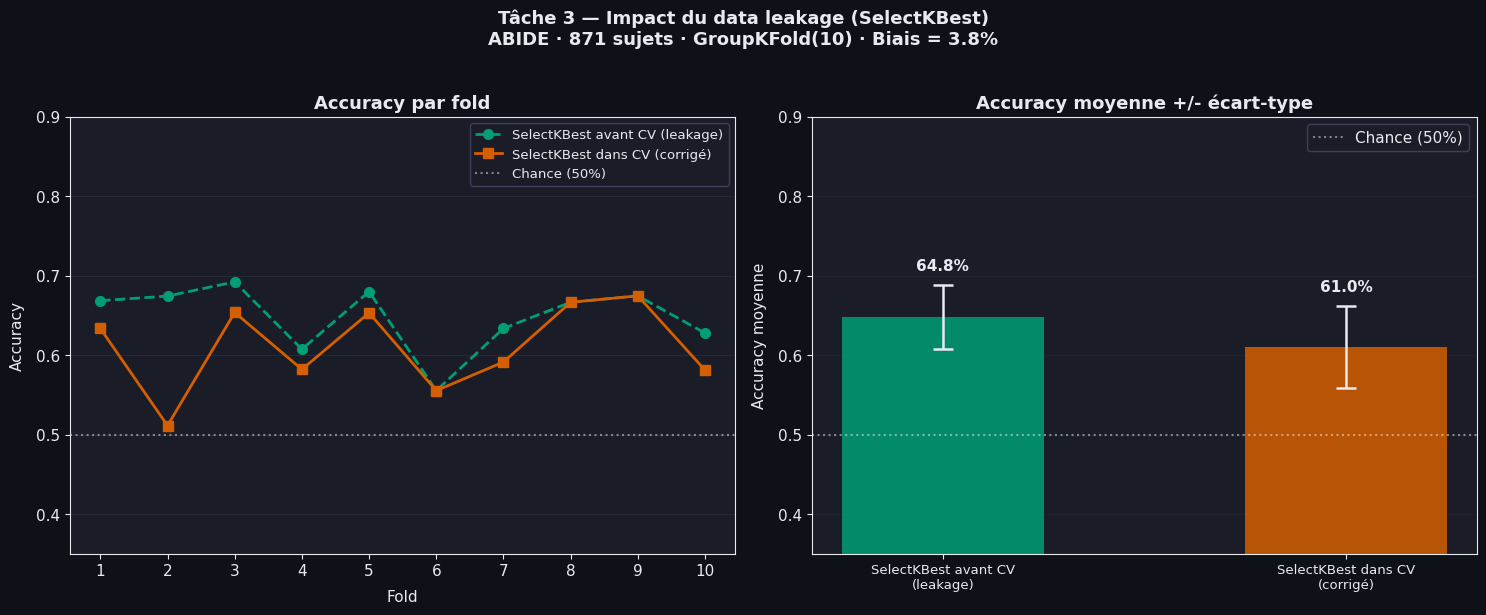

In [5]:
BG     = '#0e1117'
PANEL  = '#1a1d27'
TEXT   = '#e8eaf0'
COLORS = ['#009E73', '#D55E00']
LABELS = ['SelectKBest avant CV (leakage)', 'SelectKBest dans CV (corrigé)']

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor':   TEXT, 'axes.labelcolor': TEXT,
    'xtick.color':      TEXT, 'ytick.color':     TEXT,
    'text.color':       TEXT, 'legend.facecolor': PANEL,
    'legend.edgecolor': '#444466', 'font.size': 11,
    'axes.titlesize':   13, 'axes.titleweight': 'bold',
    'grid.color':       '#2a2d3a', 'grid.linewidth': 0.6,
})

all_scores = [scores_leakage, scores_corrected]
n_folds    = len(scores_leakage)
folds      = np.arange(n_folds)
markers    = ['o', 's']
lines      = ['--', '-']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)

# Panel gauche : accuracy par fold
ax = axes[0]
for scores, label, color, marker, line in zip(all_scores, LABELS, COLORS, markers, lines):
    ax.plot(folds, scores, marker=marker, linestyle=line, label=label,
            color=color, linewidth=2, markersize=7)
ax.axhline(0.5, color=TEXT, linestyle=':', linewidth=1.5, alpha=0.5, label='Chance (50%)')
ax.set_xlabel('Fold', labelpad=8)
ax.set_ylabel('Accuracy', labelpad=8)
ax.set_title('Accuracy par fold')
ax.set_xticks(folds)
ax.set_xticklabels([str(i + 1) for i in folds])
ax.set_ylim(0.35, 0.90)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(framealpha=0.85, fontsize=9.5)

# Panel droit : accuracy moyenne +/- écart-type
ax    = axes[1]
means = [s.mean() for s in all_scores]
stds  = [s.std()  for s in all_scores]
x_pos = np.arange(2)
bars  = ax.bar(x_pos, means, yerr=stds, capsize=7,
               color=COLORS, alpha=0.85, width=0.5,
               error_kw={'ecolor': TEXT, 'elinewidth': 1.8, 'capthick': 1.8})
ax.axhline(0.5, color=TEXT, linestyle=':', linewidth=1.5, alpha=0.5, label='Chance (50%)')
ax.set_ylabel('Accuracy moyenne', labelpad=8)
ax.set_title('Accuracy moyenne +/- écart-type')
ax.set_xticks(x_pos)
ax.set_xticklabels(['SelectKBest avant CV\n(leakage)', 'SelectKBest dans CV\n(corrigé)'], fontsize=9.5)
ax.set_ylim(0.35, 0.90)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(framealpha=0.85)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + std + 0.015,
            f'{mean:.1%}', ha='center', va='bottom',
            fontweight='bold', color=TEXT, fontsize=11)

bias = abs(means[0] - means[1])
fig.suptitle(
    f'Tâche 3 — Impact du data leakage (SelectKBest)\n'
    f'ABIDE · {X.shape[0]} sujets · GroupKFold(10) · Biais = {bias:.1%}',
    fontsize=13, fontweight='bold', color=TEXT, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Tache_3a_selectkbest_leakage.png'), bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()